In [1]:
import numpy as np
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

# Generate 10 input features spanning multiple orders of magnitude
X = np.random.rand(100, 10) * np.logspace(0, 9, 10)
# Generate a target feature that is a linear combination of the input features
W_target = np.random.uniform(0.1, 100, 10)
y = np.dot(X, W_target) + np.random.normal(0, 0.1, 100)

# Generate 20 additional features that are not used to generate the target feature
X_additional = np.random.rand(100, 20) * np.logspace(0, 9, 20)

# Combine all features into one DataFrame
data = pd.DataFrame(np.hstack((X, X_additional)), columns=[f'feature_{i}' for i in range(30)])
data['target'] = y

data.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,target
0,0.374540,9.507143,73.199394,598.658484,1560.186404,15599.452034,58083.612168,8.661761e+06,6.011150e+07,7.080726e+08,...,4749.105788,399111.474532,1.853728e+05,1.434755e+06,9.474340e+06,6.097125e+06,9.233522e+07,2.795820e+08,5.074677e+08,3.693721e+10
1,0.020584,9.699099,83.244264,212.339111,1818.249672,18340.450985,304242.242960,5.247564e+06,4.319450e+07,2.912291e+08,...,87889.608015,465407.317495,4.917660e+05,2.708465e+06,1.187660e+07,3.887876e+06,1.057979e+08,2.311171e+08,6.783706e+07,1.581817e+10
2,0.611853,1.394939,29.214465,366.361843,4560.699842,78517.596139,199673.782158,5.142344e+06,5.924146e+07,4.645041e+07,...,21123.101081,366463.312840,3.536705e+04,9.471828e+04,4.123684e+06,1.853272e+07,8.696651e+07,2.295748e+08,4.459027e+08,4.215451e+09
3,0.607545,1.705241,6.505159,948.885537,9656.320331,80839.734812,304613.769173,9.767211e+05,6.842330e+07,4.401525e+08,...,44371.246370,459545.726276,2.172892e+05,1.850969e+06,1.202426e+07,1.591896e+07,7.207923e+07,1.335845e+08,2.742152e+08,2.338831e+10
4,0.122038,4.951769,3.438852,909.320402,2587.799816,66252.228435,311711.076089,5.200680e+06,5.467103e+07,1.848545e+08,...,30125.201692,419799.517434,1.117096e+06,3.300573e+06,1.076486e+07,2.886328e+07,7.069012e+07,4.409589e+07,3.252618e+07,1.089369e+10


In [2]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data.drop(columns=['target']), data['target'], test_size=0.2, random_state=42)

def custom_log_loss(y_true, y_pred):
    """Compute custom log loss."""
    log_y_true = tf.math.log(tf.clip_by_value(y_true, 1e-10, tf.float32.max), 10) 
    log_y_pred = tf.math.log(tf.clip_by_value(y_pred, 1e-10, tf.float32.max), 10) 
    return tf.reduce_mean(tf.square(log_y_true - log_y_pred))

# Perform regression with ridge regularization and custom log loss
def custom_ridge_regression(x, y, alpha, epochs=300, learning_rate=0.1, verbose=True):
    x_min = np.min(x, axis=0)
    x_max = np.max(x, axis=0)
    x_normalized = (x - x_min) / (x_max - x_min + 1e-10)

    x_tf = tf.convert_to_tensor(x_normalized, dtype=tf.float32)
    y_tf = tf.convert_to_tensor(y.reshape(-1, 1), dtype=tf.float32)
    w = tf.Variable(tf.random.uniform((x.shape[1], 1), -10, 10, dtype=tf.float32))
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    def compute_total_loss():
        y_pred = tf.matmul(x_tf, w)
        loss = custom_log_loss(y_tf, y_pred)
        ridge_penalty = alpha * tf.math.log(tf.reduce_sum(tf.square(w)), 10)
        return loss + ridge_penalty

    for epoch in range(epochs):
        with tf.GradientTape() as tape:
            total_loss = compute_total_loss()
        gradients = tape.gradient(total_loss, [w])
        optimizer.apply_gradients(zip(gradients, [w]))

        if epoch % 10 == 0 and verbose:
            print(f"Epoch {epoch}: Loss={total_loss.numpy():.6f}")

    coef_normalized = w.numpy().flatten()
    coef_original = coef_normalized * (x_max - x_min + 1e-10) + x_min

    return coef_original

# Use the custom ridge regression function
alpha = 0.1
coefficients = custom_ridge_regression(X_train.values, y_train.values, alpha)
print(f'Coefficients: {coefficients}')


Epoch 0: Loss=535.938171
Epoch 10: Loss=441.460693
Epoch 20: Loss=403.207184
Epoch 30: Loss=394.040649
Epoch 40: Loss=387.932465
Epoch 50: Loss=383.310089
Epoch 60: Loss=379.534149
Epoch 70: Loss=376.302063
Epoch 80: Loss=373.454315
Epoch 90: Loss=370.898132
Epoch 100: Loss=368.573975
Epoch 110: Loss=366.440765
Epoch 120: Loss=364.468262
Epoch 130: Loss=362.633362
Epoch 140: Loss=360.917725
Epoch 150: Loss=359.306610
Epoch 160: Loss=357.787933
Epoch 170: Loss=356.351501
Epoch 180: Loss=354.988831
Epoch 190: Loss=353.692566
Epoch 200: Loss=352.456604
Epoch 210: Loss=351.275452
Epoch 220: Loss=350.144440
Epoch 230: Loss=349.059418
Epoch 240: Loss=348.016815
Epoch 250: Loss=347.013336
Epoch 260: Loss=346.046143
Epoch 270: Loss=345.112671
Epoch 280: Loss=344.210663
Epoch 290: Loss=343.337982
Coefficients: [9.72568523e+00 1.36252364e+02 1.57620337e+03 1.53337892e+04
 1.18418276e+05 9.41111808e+05 7.75953755e+06 1.34958927e+08
 2.16791473e+09 8.66219873e+09 1.09552619e+01 3.72854198e+01
 1.2

   Real Coefficients  Calculated Coefficients    Difference
0          18.594780             9.725685e+00  8.869094e+00
1          54.235905             1.362524e+02 -8.201646e+01
2          87.307289             1.576203e+03 -1.488896e+03
3          73.249266             1.533379e+04 -1.526054e+04
4          80.675459             1.184183e+05 -1.183376e+05
5          65.912458             9.411118e+05 -9.410459e+05
6          69.258429             7.759538e+06 -7.759468e+06
7          84.934646             1.349589e+08 -1.349588e+08
8          25.041834             2.167915e+09 -2.167915e+09
9          48.993554             8.662199e+09 -8.662199e+09


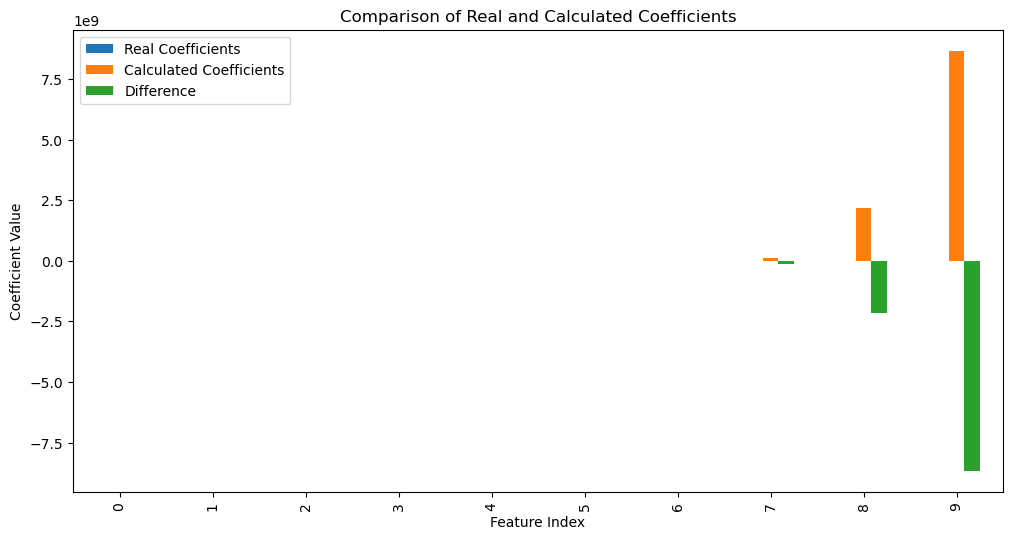

In [3]:
import matplotlib.pyplot as plt 

# Actual real coefficients
real_coefficients = W_target

# Calculated coefficients from custom ridge regression
calculated_coefficients = coefficients[:10]  # Only the first 10 coefficients are relevant

# Compare the coefficients
comparison = pd.DataFrame({
    'Real Coefficients': real_coefficients,
    'Calculated Coefficients': calculated_coefficients,
    'Difference': real_coefficients - calculated_coefficients
})

print(comparison)

# Plot the comparison
comparison.plot(kind='bar', figsize=(12, 6))
plt.title('Comparison of Real and Calculated Coefficients')
plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.show()